# Breast Cancer Random Forest

**Programmer:** Hasmik Galstyan  
**Description:** Explores and encodes the breast cancer dataset, tunes a Random Forest classifier, and checks model performance with cross-validation.

In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
# Load the breast cancer dataset
file_path = "breast_cancer_prediction.csv"
df = pd.read_csv(file_path, encoding="latin1")

Dataset Describtion

In [3]:
df.head(20)

,Patient_ID,Age,Gender,BMI,Family_History,Smoking,Alcohol_Consumption,Physical_Activity,Hormone_Therapy,Menopause_Status,...,Mammogram_Result,Biopsy_Result,Cancer_Stage,Cancer,Blood_Pressure,Cholesterol,Diabetes,Exercise_Days_Per_Week,Breastfeeding_History,Annual_Income_USD
0,100001,71,Female,27.2,Yes,Yes,Yes,High,No,Post,...,Suspicious,Malignant,Stage II,1,141,167,No,7,No,101316
1,100002,34,Male,26.0,No,No,No,High,No,Post,...,Normal,Benign,No Cancer,0,104,229,Yes,7,Yes,30023
2,100003,80,Female,20.7,No,No,No,High,No,Pre,...,Suspicious,Benign,No Cancer,0,161,275,No,1,Yes,34819
3,100004,40,Female,26.8,Yes,Yes,No,Moderate,No,Post,...,Normal,Benign,No Cancer,0,150,180,No,7,Yes,68025
4,100005,43,Female,28.6,Yes,Yes,No,Moderate,No,Post,...,Normal,Benign,No Cancer,0,110,266,No,0,Yes,90919
5,100006,22,Female,18.8,No,No,No,Moderate,No,Post,...,Normal,Benign,No Cancer,0,172,270,No,3,Yes,51320
6,100007,41,Female,31.8,Yes,No,Yes,High,No,Post,...,Normal,Benign,No Cancer,0,176,297,No,7,No,47235
7,100008,72,Male,23.8,No,Yes,No,High,No,Post,...,Normal,Benign,No Cancer,0,164,184,No,5,Yes,102525
8,100009,21,Female,26.1,No,No,No,High,No,Post,...,Normal,Benign,No Cancer,0,164,238,No,0,Not Applicable,47668
9,100010,49,Female,29.7,Yes,No,Yes,Moderate,No,Pre,...,Normal,Benign,No Cancer,0,177,300,No,0,Yes,83068


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patient_ID              10000 non-null  int64  
 1   Age                     10000 non-null  int64  
 2   Gender                  10000 non-null  object 
 3   BMI                     9700 non-null   float64
 4   Family_History          10000 non-null  object 
 5   Smoking                 10000 non-null  object 
 6   Alcohol_Consumption     9700 non-null   object 
 7   Physical_Activity       9700 non-null   object 
 8   Hormone_Therapy         9700 non-null   object 
 9   Menopause_Status        10000 non-null  object 
 10  Genetic_Mutation        10000 non-null  object 
 11  Tumor_Size_cm           9700 non-null   float64
 12  Lymph_Node_Involvement  10000 non-null  object 
 13  Mammogram_Result        10000 non-null  object 
 14  Biopsy_Result           10000 non-null 

In [5]:
df.shape

(10000, 23)

In [6]:
df.describe()

,Patient_ID,Age,BMI,Tumor_Size_cm,Cancer,Blood_Pressure,Cholesterol,Exercise_Days_Per_Week,Annual_Income_USD
count,10000.00000,10000.000000,9700.000000,9700.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,105000.50000,52.033800,27.051227,2.630334,0.193300,134.811100,214.071500,3.535200,82337.305000
std,2886.89568,18.789517,4.494501,1.589789,0.394906,26.174742,49.242034,2.282385,39102.629984
min,100001.00000,20.000000,11.100000,0.000000,0.000000,90.000000,130.000000,0.000000,15002.000000
25%,102500.75000,36.000000,24.000000,1.370000,0.000000,112.000000,172.000000,2.000000,48145.750000
50%,105000.50000,52.000000,27.000000,2.510000,0.000000,135.000000,213.000000,4.000000,81813.500000
75%,107500.25000,68.000000,30.100000,3.720000,0.000000,157.000000,257.000000,6.000000,116217.500000
max,110000.00000,84.000000,44.100000,9.880000,1.000000,180.000000,300.000000,7.000000,149996.000000


In [7]:
df.isna().sum()

Patient_ID                  0
Age                         0
Gender                      0
BMI                       300
Family_History              0
Smoking                     0
Alcohol_Consumption       300
Physical_Activity         300
Hormone_Therapy           300
Menopause_Status            0
Genetic_Mutation            0
Tumor_Size_cm             300
Lymph_Node_Involvement      0
Mammogram_Result            0
Biopsy_Result               0
Cancer_Stage                0
Cancer                      0
Blood_Pressure              0
Cholesterol                 0
Diabetes                    0
Exercise_Days_Per_Week      0
Breastfeeding_History       0
Annual_Income_USD           0
dtype: int64

In [8]:
# Remove rows with missing values
df = df.dropna()

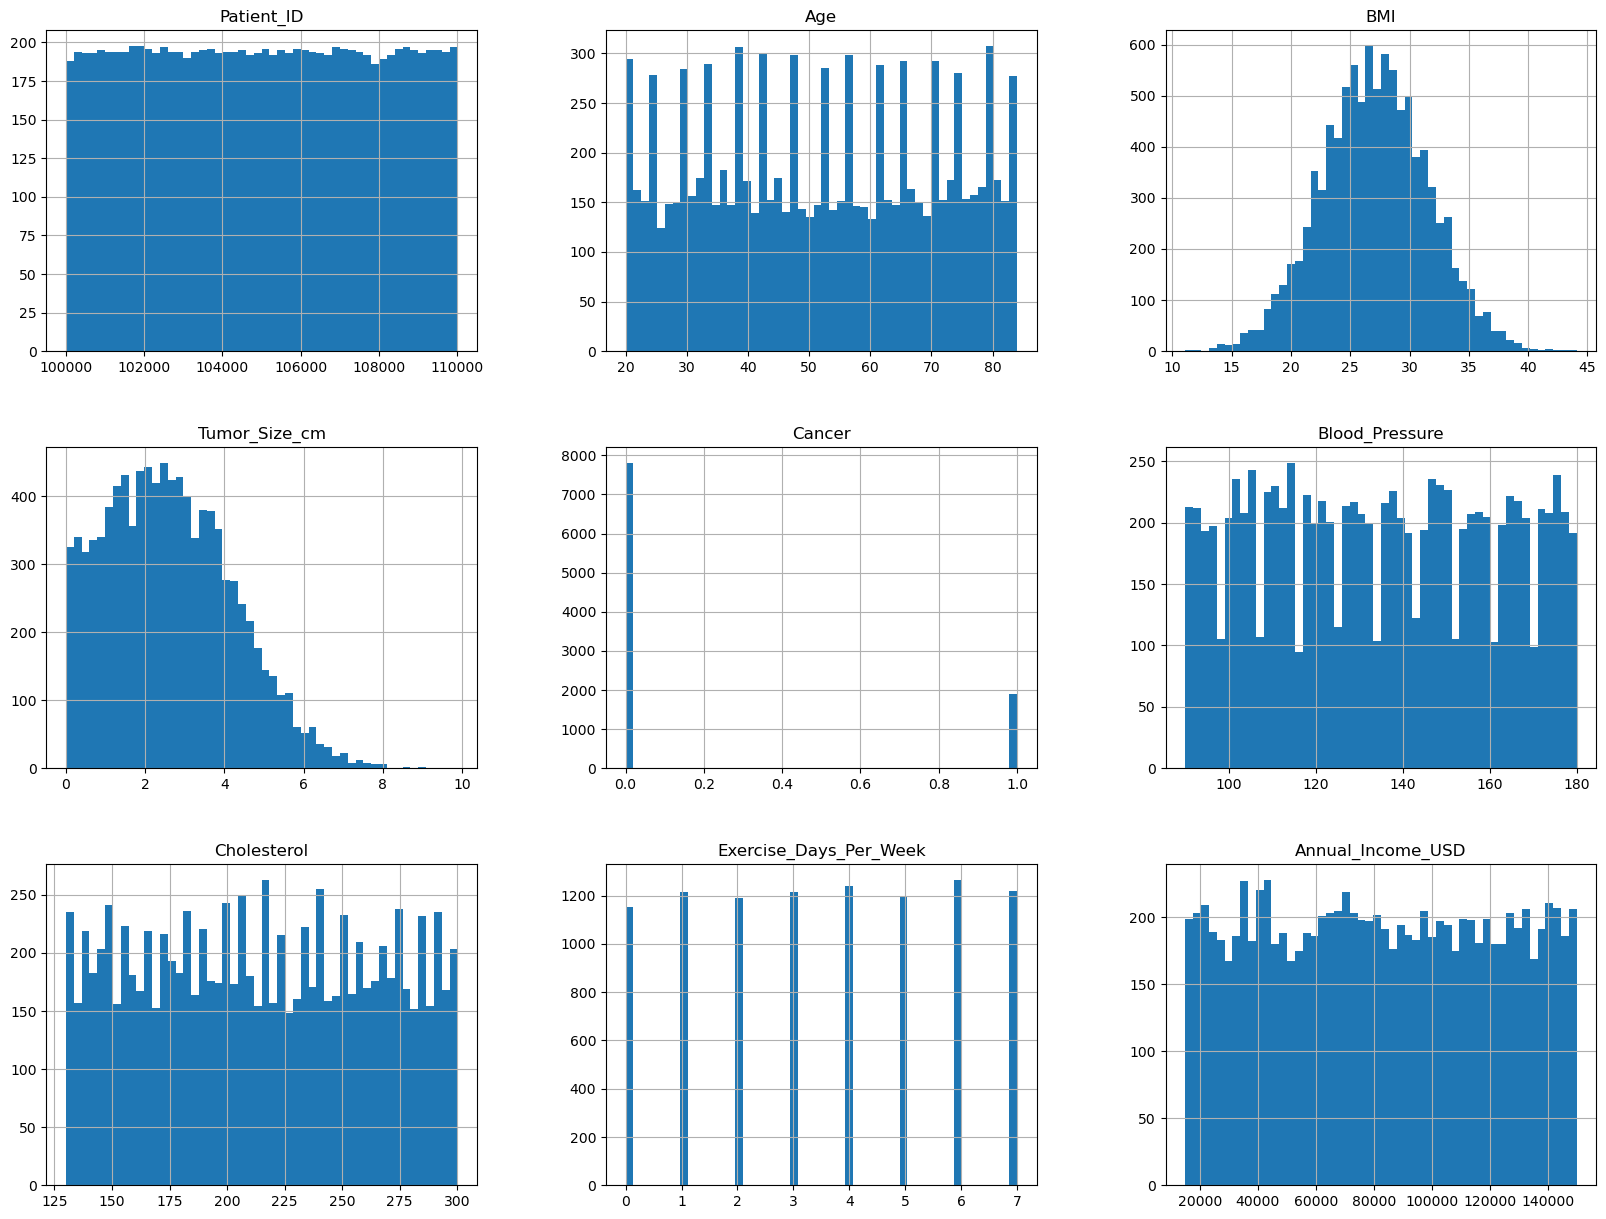

In [9]:
# View the numeric feature distributions
import matplotlib.pyplot as plt

df.hist(bins=50, figsize=(20, 15))
plt.show()

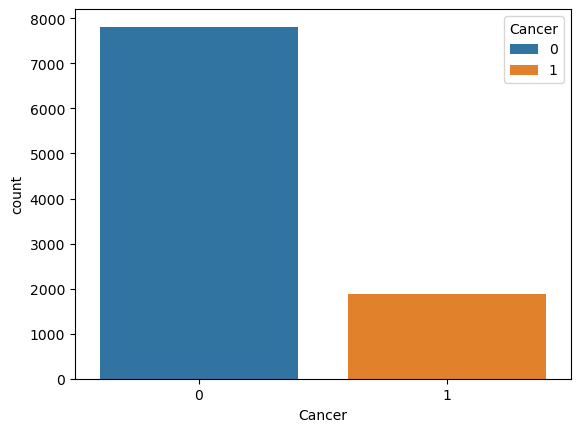

In [10]:
# Compare the number of cancer and no-cancer records
p = sns.countplot(data=df, x="Cancer", hue = "Cancer")

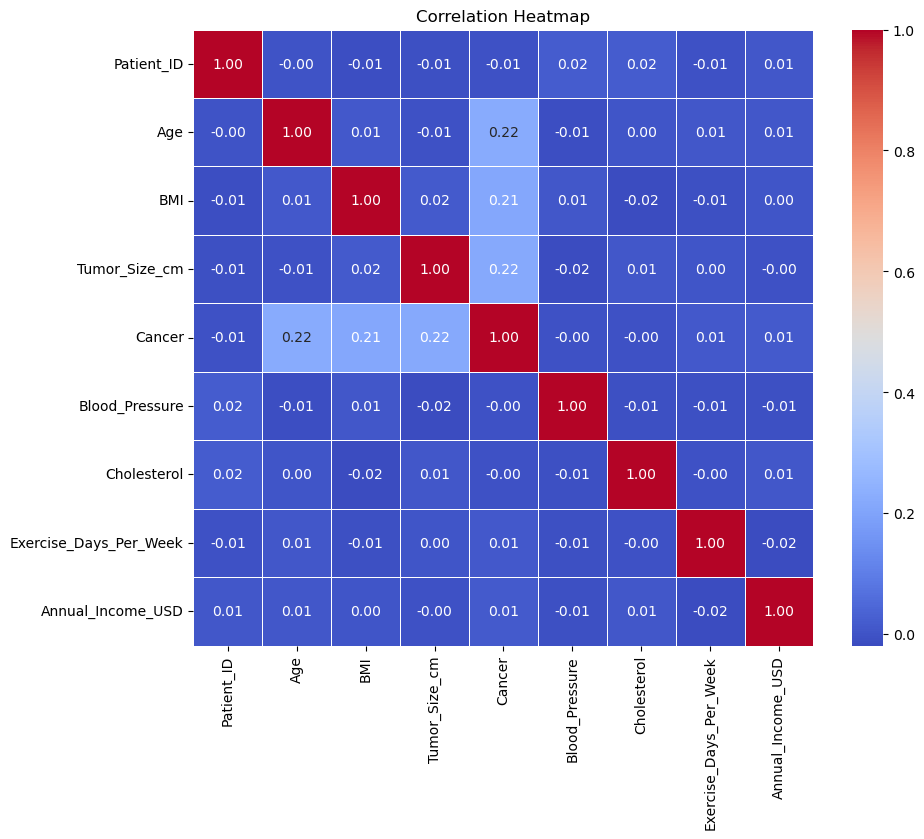

In [11]:
corr_matrix = df.select_dtypes(include="number").corr()

# Draw the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

Output classes are imbalanced. 

Data Encoding 

In [12]:
# Set input and output features
X = df.drop(columns=["Cancer", "Patient_ID", "Cancer_Stage", "Mammogram_Result","Biopsy_Result","Lymph_Node_Involvement"])
y = df["Cancer"]

In [13]:
# Create training/testing split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123, stratify=y)

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from category_encoders import BinaryEncoder

# 3. Define columns
low_card_cols = ["Physical_Activity", "Breastfeeding_History"]
high_card_cols = ["Gender", "Family_History", "Smoking", "Alcohol_Consumption", 
                  "Hormone_Therapy", "Menopause_Status", "Genetic_Mutation", 
                   "Diabetes"]

# 4. Bundle encoders (Fixed BinaryEncoder arguments)
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), low_card_cols),
        ('binary', BinaryEncoder(handle_missing='value'), high_card_cols)
    ],
    remainder='passthrough'
)

# 5. Fit and transform
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)


In [15]:
# Get the engineered feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Convert the encoded NumPy arrays back into pandas DataFrames
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=feature_names, index=X_train.index)
X_test_encoded_df  = pd.DataFrame(X_test_encoded, columns=feature_names, index=X_test.index)


In [16]:
# Preview the encoded training data
X_train_encoded_df.head()

,onehot__Physical_Activity_High,onehot__Physical_Activity_Low,onehot__Physical_Activity_Moderate,onehot__Breastfeeding_History_No,onehot__Breastfeeding_History_Not Applicable,onehot__Breastfeeding_History_Yes,binary__Gender_0,binary__Gender_1,binary__Family_History_0,binary__Family_History_1,...,binary__Genetic_Mutation_1,binary__Diabetes_0,binary__Diabetes_1,remainder__Age,remainder__BMI,remainder__Tumor_Size_cm,remainder__Blood_Pressure,remainder__Cholesterol,remainder__Exercise_Days_Per_Week,remainder__Annual_Income_USD
7914,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,57.0,29.2,1.53,93.0,274.0,7.0,29518.0
2513,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,84.0,28.4,0.67,149.0,158.0,0.0,34451.0
9082,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,21.0,25.8,2.32,109.0,183.0,1.0,135547.0
3695,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,43.0,30.1,3.15,170.0,276.0,1.0,144012.0
4653,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,25.0,22.2,2.43,130.0,276.0,3.0,140276.0


In [17]:
# Preview the encoded test data
X_test_encoded_df.head()

,onehot__Physical_Activity_High,onehot__Physical_Activity_Low,onehot__Physical_Activity_Moderate,onehot__Breastfeeding_History_No,onehot__Breastfeeding_History_Not Applicable,onehot__Breastfeeding_History_Yes,binary__Gender_0,binary__Gender_1,binary__Family_History_0,binary__Family_History_1,...,binary__Genetic_Mutation_1,binary__Diabetes_0,binary__Diabetes_1,remainder__Age,remainder__BMI,remainder__Tumor_Size_cm,remainder__Blood_Pressure,remainder__Cholesterol,remainder__Exercise_Days_Per_Week,remainder__Annual_Income_USD
8659,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,26.0,23.0,2.18,110.0,293.0,4.0,76356.0
9326,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,22.0,33.8,0.46,105.0,160.0,3.0,113245.0
815,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,46.0,31.3,4.07,156.0,146.0,7.0,72283.0
1836,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,71.0,21.4,3.53,151.0,231.0,1.0,137829.0
7127,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,49.0,31.8,3.30,126.0,216.0,1.0,99160.0


Grid Search on Random Forest  - Finding Best Model 

In [18]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

In [19]:
# Search for the best Random Forest settings
rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train_encoded_df, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [29]:
# Print the optimal hyperparameter combination
print("Best Hyperparameters found:", grid_search.best_params_)

# Retrieve the best model object
best_rf_model = grid_search.best_estimator_

# Make predictions and evaluate accuracy
predictions = best_rf_model.predict(X_test_encoded_df)
test_accuracy = accuracy_score(y_test, predictions)
print(f"Test Accuracy of Best Model: {test_accuracy:.4f}")
print("Testing precision of Best Model:", precision_score(y_test, predictions))
confusion_matrix(y_test, predictions)

Best Hyperparameters found: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Test Accuracy of Best Model: 0.8730
Testing precision of Best Model: 0.8106060606060606


array([[1903,   50],
       [ 258,  214]])

Random Forest Model with max_feature = "sqrt"

In [21]:
from sklearn.ensemble import RandomForestClassifier

randomForest = RandomForestClassifier( n_estimators=100,
    max_depth=8,                     
    min_samples_split=10,             
    min_samples_leaf=5,               
    max_features="sqrt",              
    class_weight="balanced",          
    random_state=456)
randomForest.fit(X_train_encoded_df, np.ravel(y_train))

RandomForestClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=5,
                       min_samples_split=10, random_state=456)

In [22]:
from sklearn.metrics import  confusion_matrix, accuracy_score, precision_score, recall_score
predtrain = randomForest.predict(X_train_encoded_df)
predtest = randomForest.predict(X_test_encoded_df)

In [23]:
# Compare training and testing accuracy
print("Training accuracy:", accuracy_score(y_train, predtrain))
print("Testing accuracy:", accuracy_score(y_test, predtest))

Training accuracy: 0.8827491408934708
Testing accuracy: 0.8729896907216494


In [24]:
# Compare precision on seen and unseen data
print("Training precision:", precision_score(y_train, predtrain))
print("Testing precision:", precision_score(y_test, predtest))

Training precision: 0.6432212028542303
Testing precision: 0.6273291925465838


In [25]:
confusion_matrix(y_train, predtrain)

array([[5160,  700],
       [ 153, 1262]])

In [26]:
confusion_matrix(y_test, predtest)

array([[1713,  240],
       [  68,  404]])

K-Folds Cross Validation 

In [27]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from category_encoders import BinaryEncoder


# 2. Separate Inputs and Targets
X = df.drop(columns=df[["Cancer", "Patient_ID", "Cancer_Stage", "Mammogram_Result","Biopsy_Result","Lymph_Node_Involvement"]])
y = df["Cancer"]

# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123, stratify=y)

# 3. Categorize EVERY column explicitly to avoid raw passthroughs
low_card_cols = ["Physical_Activity", "Breastfeeding_History"]

# Only pass truly high-cardinality strings to BinaryEncoder (e.g., professions, regions)
# Keep standard binary/low-tier flags in OneHot to prevent column explosion
high_card_cols = ["Gender", "Family_History", "Smoking", "Alcohol_Consumption", 
                  "Hormone_Therapy", "Menopause_Status", "Genetic_Mutation", "Diabetes"]

# Automatically detect any remaining numeric columns (Age, Blood metrics, etc.)
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# 4. Comprehensive Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), low_card_cols),
        ('binary', BinaryEncoder(handle_missing='value'), high_card_cols),
        ('scaler', StandardScaler(), num_cols) # Scales continuous values so they don't dominate splits
    ],
    remainder='drop' # Explicitly drop unhandled data to prevent structural leaks
)

# 5. Process Features safely
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_encoded, columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_encoded, columns=feature_names, index=X_test.index)

# 6. Heavily Regularized Random Forest Classifier
# Stripping depth down significantly and setting rigid floor limits for leaf nodes
randomForest = RandomForestClassifier(
    n_estimators=150,
    max_depth=5,                      # Drop from 8 down to 5 to completely flatten memorization paths
    min_samples_split=25,             # Demands massive consensus before creating a tree node split
    min_samples_leaf=15,              # Every single ending rule must apply to at least 15 distinct patients
    max_features="log2",              # Inspects fewer features per split to maximize tree diversity
    class_weight="balanced",          
    random_state=456,
    n_jobs=-1
)

# 7. Validate Stability Using Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
cv_results = cross_validate(randomForest, X_train_df, np.ravel(y_train), cv=cv, scoring='accuracy', return_train_score=True)

print(f"Cross-Val Training Accuracy: {cv_results['train_score'].mean():.4f}")
print(f"Cross-Val Validation Accuracy: {cv_results['test_score'].mean():.4f}\n")

# 8. Final Fit and Evaluation
randomForest.fit(X_train_df, np.ravel(y_train))
predtrain = randomForest.predict(X_train_df)
predtest = randomForest.predict(X_test_df)

print("--- Final Evaluation Metrics ---")
print("Train Confusion Matrix:\n", confusion_matrix(y_train, predtrain))
print("Test Confusion Matrix:\n", confusion_matrix(y_test, predtest))

print("\nDetailed Test Performance:")
print(classification_report(y_test, predtest))


Cross-Val Training Accuracy: 0.8570
Cross-Val Validation Accuracy: 0.8544

--- Final Evaluation Metrics ---
Train Confusion Matrix:
 [[4983  877]
 [ 166 1249]]
Test Confusion Matrix:
 [[1680  273]
 [  64  408]]

Detailed Test Performance:
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      1953
           1       0.60      0.86      0.71       472

    accuracy                           0.86      2425
   macro avg       0.78      0.86      0.81      2425
weighted avg       0.89      0.86      0.87      2425

